In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import numpy as np
import sklearn

In [40]:
# import the dataset
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)
df = pd.read_csv(config["input_data"]["file_1"])

In [41]:
# check quickly data content
print(df.isnull().sum())
print(df.dtypes)

print(
    df.select_dtypes(include=["object", "string"])
      .nunique()
      .sort_values(ascending=False)
)

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               obje

In [42]:
df.dtypes.value_counts()

object     9
float64    8
Name: count, dtype: int64

In [43]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns
print(categorical_cols)

Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')


In [44]:
df.duplicated().sum()

np.int64(24)

In [45]:
df = df.drop_duplicates()

In [46]:
df["NObeyesdad"].nunique()

7

In [47]:
df["NObeyesdad"].unique()

array(['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II',
       'Obesity_Type_III'], dtype=object)

In [48]:
df["NObeyesdad"].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64

In [50]:
target = "NObeyesdad"

X = df.drop(columns=[target]).copy()
y = df[target].copy()

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
bin_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
ord_cols = ['CAEC', 'CALC']
nom_cols = ['MTRANS']

In [53]:
X_train['BMI'] = X_train['Weight'] / (X_train['Height'] ** 2)
X_test['BMI'] = X_test['Weight'] / (X_test['Height'] ** 2)

num_cols = num_cols + ['BMI']

In [54]:
bin_map = {
    'Male': 0,
    'Female': 1,
    'no': 0,
    'yes': 1
}

for col in bin_cols:
    X_train[col] = X_train[col].map(bin_map)
    X_test[col] = X_test[col].map(bin_map)

In [55]:
caec_map = {
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
}

calc_map = {
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
}

X_train['CAEC'] = X_train['CAEC'].map(caec_map)
X_test['CAEC'] = X_test['CAEC'].map(caec_map)

X_train['CALC'] = X_train['CALC'].map(calc_map)
X_test['CALC'] = X_test['CALC'].map(calc_map)

In [56]:
X_train = pd.get_dummies(X_train, columns=nom_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nom_cols, drop_first=True)

In [57]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [58]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [59]:
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(class_mapping)

{'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}


In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train_encoded)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [63]:
y_pred = knn.predict(X_test_scaled)

In [64]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.8205741626794258

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.71      0.94      0.81        53
      Normal_Weight       0.56      0.49      0.52        57
     Obesity_Type_I       0.90      0.91      0.91        70
    Obesity_Type_II       0.95      0.97      0.96        60
   Obesity_Type_III       0.97      1.00      0.98        65
 Overweight_Level_I       0.76      0.64      0.69        55
Overweight_Level_II       0.81      0.74      0.77        58

           accuracy                           0.82       418
          macro avg       0.81      0.81      0.81       418
       weighted avg       0.82      0.82      0.82       418



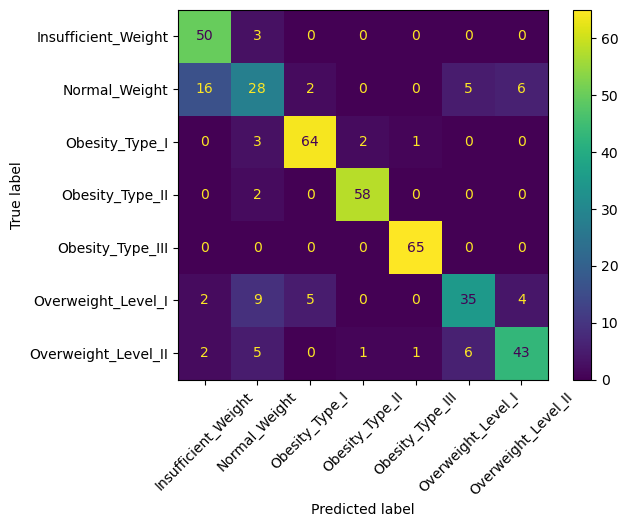

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test_encoded, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation=45)
plt.show()

In [66]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': list(range(3, 16)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train_encoded)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Best CV score: 0.9107226987466509


In [67]:
best_knn = grid.best_estimator_

y_pred_best = best_knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test_encoded, y_pred_best))
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred_best, target_names=label_encoder.classes_))

Accuracy: 0.8971291866028708

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.86      0.94      0.90        53
      Normal_Weight       0.71      0.70      0.71        57
     Obesity_Type_I       0.91      0.96      0.93        70
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.90      0.78      0.83        55
Overweight_Level_II       0.88      0.90      0.89        58

           accuracy                           0.90       418
          macro avg       0.89      0.89      0.89       418
       weighted avg       0.90      0.90      0.90       418



In [68]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_knn,
    X_test_scaled,
    y_test_encoded,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': perm.importances_mean
}).sort_values(by='importance_mean', ascending=False)

print(feature_importance)

                           feature  importance_mean
15                             BMI         0.045215
14                            CALC         0.040431
18    MTRANS_Public_Transportation         0.038038
3                           Weight         0.032057
2                           Height         0.031579
0                           Gender         0.027512
7                              NCP         0.023206
1                              Age         0.022727
13                             TUE         0.021770
8                             CAEC         0.020813
12                             FAF         0.011962
10                            CH2O         0.009091
4   family_history_with_overweight         0.009091
5                             FAVC         0.006699
11                             SCC         0.006220
19                  MTRANS_Walking         0.004785
6                             FCVC         0.002392
9                            SMOKE         0.001675
16          

In [69]:
predicted_labels = label_encoder.inverse_transform(y_pred_best)
print(predicted_labels[:10])

['Overweight_Level_II' 'Obesity_Type_I' 'Obesity_Type_III'
 'Overweight_Level_I' 'Obesity_Type_I' 'Obesity_Type_I' 'Obesity_Type_I'
 'Overweight_Level_II' 'Obesity_Type_III' 'Obesity_Type_II']


In [70]:
cols_to_drop = ['MTRANS_Bike', 'MTRANS_Motorbike']

X_train_red = X_train.drop(columns=cols_to_drop)
X_test_red = X_test.drop(columns=cols_to_drop)

In [71]:
cols_to_drop = [
    'SMOKE',
    'FCVC',
    'SCC'
]

X_train_red = X_train.drop(columns=cols_to_drop)
X_test_red = X_test.drop(columns=cols_to_drop)

In [72]:
cols_to_drop = [
    'MTRANS_Bike',
    'MTRANS_Motorbike',
    'SMOKE',
    'FCVC',
    'SCC'
]

In [76]:
def evaluate_features(cols_to_drop):
    X_tr = X_train.drop(columns=cols_to_drop)
    X_te = X_test.drop(columns=cols_to_drop)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_tr, y_train_encoded)

    y_pred = model.predict(X_te)

    return accuracy_score(y_test_encoded, y_pred)

In [77]:
print("Baseline:", evaluate_features([]))

print("Remove negativos:",
      evaluate_features(['MTRANS_Bike','MTRANS_Motorbike']))

print("Remove baixos:",
      evaluate_features(['SMOKE','FCVC','SCC']))

print("Remove todos:",
      evaluate_features([
          'MTRANS_Bike','MTRANS_Motorbike',
          'SMOKE','FCVC','SCC'
      ]))

Baseline: 0.8205741626794258
Remove negativos: 0.8277511961722488
Remove baixos: 0.8277511961722488
Remove todos: 0.8325358851674641


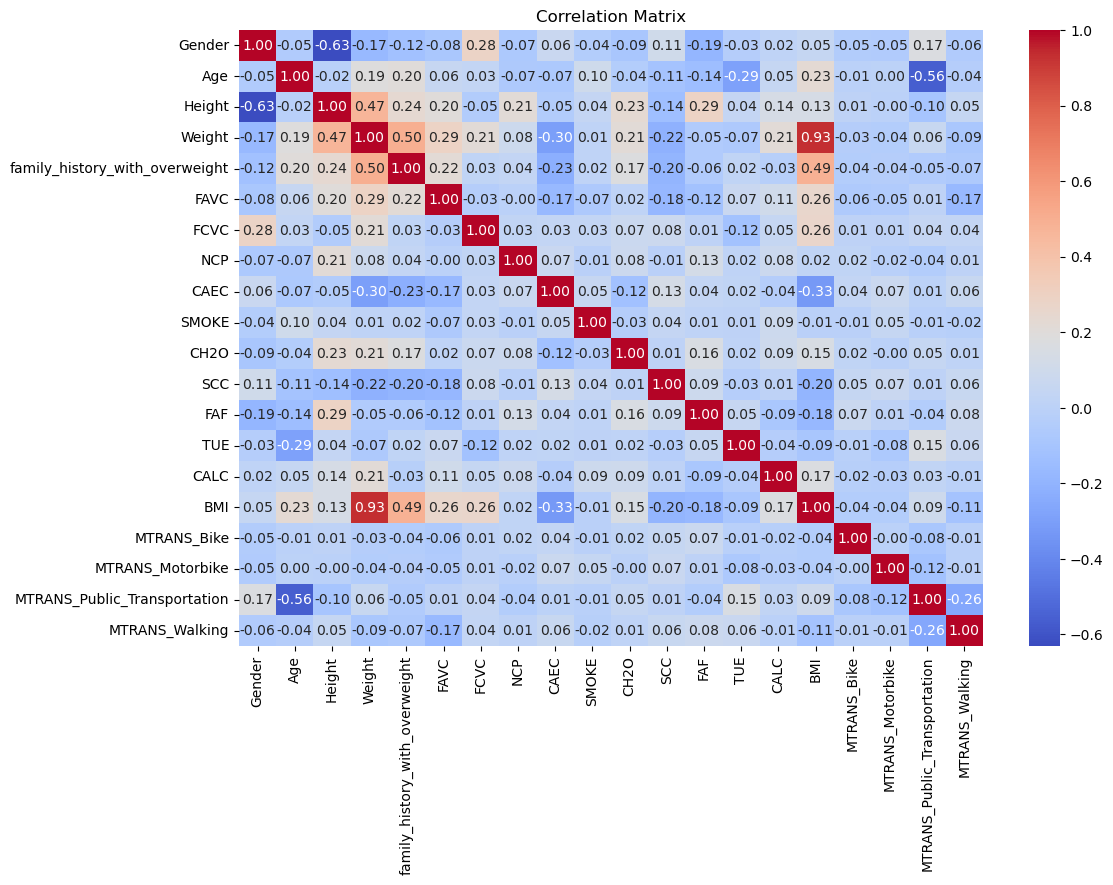

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X_train.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [79]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = X_train.select_dtypes(include=[np.number])

vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i)
                 for i in range(X_vif.shape[1])]

print(vif_df.sort_values(by="VIF", ascending=False))

                           feature         VIF
15                             BMI  208.534690
3                           Weight  179.040958
2                           Height   94.477412
6                             FCVC   27.456299
1                              Age   19.323081
7                              NCP   14.466737
10                            CH2O   13.388902
5                             FAVC    9.843102
8                             CAEC    8.567022
4   family_history_with_overweight    8.376440
0                           Gender    3.586488
14                            CALC    3.322877
12                             FAF    3.030716
13                             TUE    2.477758
11                             SCC    1.165517
9                            SMOKE    1.065700


In [80]:
cols_to_drop = [
    'Weight',
    'Height',
    'FCVC',
    'SMOKE',
    'SCC',
    'MTRANS_Bike',
    'MTRANS_Motorbike'
]

X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

In [81]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Class mapping:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Class mapping:
{'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}


In [82]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [83]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_encoded)

y_pred = knn.predict(X_test_scaled)

print("Baseline Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("\nBaseline Classification Report:\n")
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

Baseline Accuracy: 0.7942583732057417

Baseline Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.74      0.92      0.82        53
      Normal_Weight       0.55      0.49      0.52        57
     Obesity_Type_I       0.83      0.86      0.85        70
    Obesity_Type_II       0.91      0.97      0.94        60
   Obesity_Type_III       0.97      0.98      0.98        65
 Overweight_Level_I       0.71      0.67      0.69        55
Overweight_Level_II       0.77      0.62      0.69        58

           accuracy                           0.79       418
          macro avg       0.78      0.79      0.78       418
       weighted avg       0.79      0.79      0.79       418



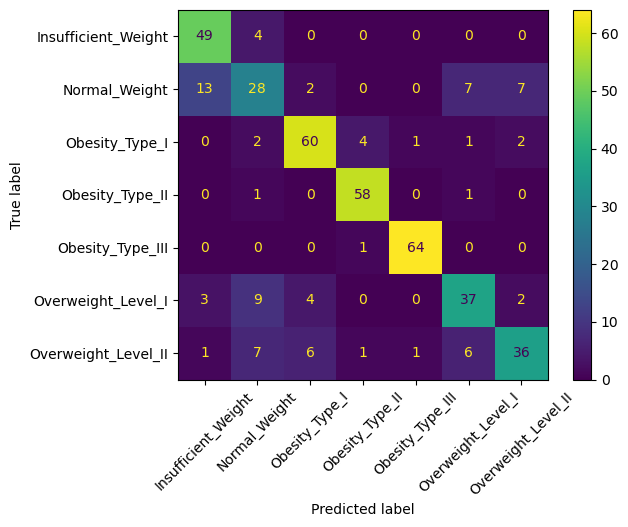

In [84]:
cm = confusion_matrix(y_test_encoded, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(xticks_rotation=45)
plt.show()

In [85]:
param_grid = {
    'n_neighbors': list(range(3, 16)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train_encoded)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)


Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV score: 0.862798726870583


In [86]:
best_knn = grid.best_estimator_
y_pred_best = best_knn.predict(X_test_scaled)

print("\nTuned Accuracy:", accuracy_score(y_test_encoded, y_pred_best))
print("\nTuned Classification Report:\n")
print(classification_report(y_test_encoded, y_pred_best, target_names=label_encoder.classes_))


Tuned Accuracy: 0.8492822966507177

Tuned Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.85      0.94      0.89        53
      Normal_Weight       0.67      0.60      0.63        57
     Obesity_Type_I       0.90      0.89      0.89        70
    Obesity_Type_II       0.97      0.98      0.98        60
   Obesity_Type_III       0.97      0.98      0.98        65
 Overweight_Level_I       0.73      0.78      0.75        55
Overweight_Level_II       0.81      0.74      0.77        58

           accuracy                           0.85       418
          macro avg       0.84      0.85      0.84       418
       weighted avg       0.85      0.85      0.85       418



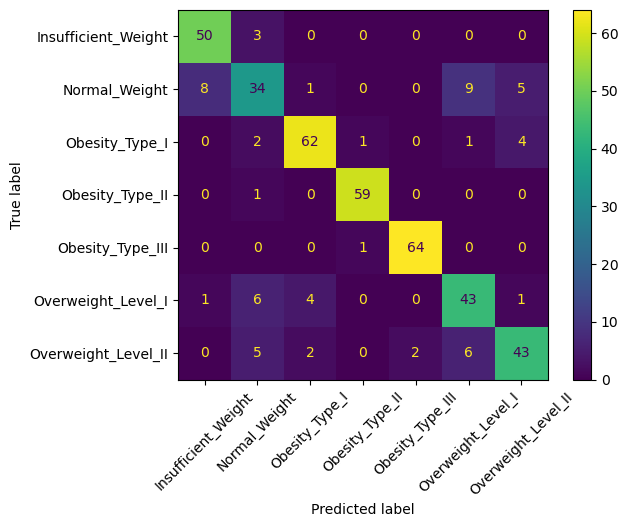

In [87]:
cm_best = confusion_matrix(y_test_encoded, y_pred_best)

disp_best = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=label_encoder.classes_
)
disp_best.plot(xticks_rotation=45)
plt.show()